In [1]:
# ============================
# CELL 1: COMMON DEFINITIONS
# ============================
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import time
from google.colab import drive
drive.mount('/content/drive')
# ===========================
# Reproducibility
# ===========================
torch.manual_seed(42)
torch.cuda.manual_seed(42)
np.random.seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
# ==========================
# Device
# ==========================
if torch.cuda.is_available():
  device = 'cuda'
  print(torch.cuda.get_device_name(0))
else:
  device = 'cpu'
print('using device:', device)
# ==========================
# PINN Model
# ==========================
LAYERS = 8
NEURONS = 256
class PINN(nn.Module):
  def __init__(self, layers=LAYERS, neurons=NEURONS):
    super().__init__()
    net = [nn.Linear(3, neurons), nn.Tanh()]
    for _ in range(layers - 1):
      net += [nn.Linear(neurons, neurons), nn.Tanh()]
    net += [nn.Linear(neurons, 1)]
    self.net = nn.Sequential(*net)
    self.initialize_weights()

  def initialize_weights(self):
    for m in self.modules():
      if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
          nn.init.zeros_(m.bias)
  def forward(self, x):
    return self.net(x)
model = PINN().to(device)
# =========================
# Hyperparameters
# =========================
N_f = 10000
N_i = 5000
T_final = 2
adam_epochs = 20000
lbfgs_epochs = 500
w_pde, w_ic , w_eik = 1.0, 10.0, 0.1
# =========================
# Velocity Field
# =========================
def velocity_field(x, y, t):
  factor = torch.cos(np.pi * t)
  u = -torch.sin(np.pi * x)**2 * torch.sin(2 * np.pi * y) * factor
  v = torch.sin(np.pi * y)**2 * torch.sin(2 * np.pi * x) * factor
  return u, v
# =========================
# Initial Condition
# =========================
def initial_condition(x, y):
  xc, yc, r = 0.5, 0.75, 0.15
  return torch.sqrt((x - xc)**2 + (y - yc)**2) - r
# =========================
# Sample Points
# =========================
torch.manual_seed(100)
torch.cuda.manual_seed(100)

X_f = torch.rand(N_f, 3, dtype=torch.float32, device=device).requires_grad_(True)

x_i = torch.rand(N_i, 1, dtype=torch.float32, device=device)
y_i = torch.rand(N_i, 1, dtype=torch.float32, device=device)
t_i = torch.zeros(N_i, 1, dtype=torch.float32, device=device)
X_i = torch.cat([x_i, y_i, t_i], dim=1)
# =========================
# Loss Function
# ========================
def physics_loss(X_f, X_i):
  # PDE Loss
  phi = model(X_f)
  grad_phi = torch.autograd.grad(phi, X_f, grad_outputs=torch.ones_like(phi), create_graph=True)[0]
  phi_x, phi_y, phi_t = grad_phi[:, 0:1], grad_phi[:, 1:2], grad_phi[:, 2:3]
  u, v = velocity_field(X_f[:, 0:1], X_f[:, 1:2], X_f[:, 2:3])
  f_pde = phi_t + T_final * (u * phi_x + v * phi_y)
  loss_pde = torch.mean(f_pde**2)
  # Initial Condition Loss
  phi_true = initial_condition(X_i[:, 0:1], X_i[:, 1:2])
  phi_pred = model(X_i)
  loss_ic = torch.mean((phi_true - phi_pred)**2)
  # Eikonal Loss
  norm_phi = torch.sqrt(phi_x**2 + phi_y**2 + 1e-8)
  loss_eik = torch.mean((norm_phi - 1)**2)

  total_loss = w_pde * loss_pde + w_ic * loss_ic + w_eik * loss_eik
  return loss_pde, loss_ic, loss_eik, total_loss

Mounted at /content/drive
Tesla T4
using device: cuda


In [2]:
# ========================
# Training
# ========================
optimizer_adam = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer_adam, step_size=1000, gamma=0.9)
start_time = time.time()
history = {'epoch': [], 'total': [], 'pde': [], 'ic': [], 'eik': []}
# Adam optimizer
for epoch in range(adam_epochs):
    optimizer_adam.zero_grad()
    loss_pde, loss_ic, loss_eik, loss = physics_loss(X_f, X_i)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer_adam.step()
    scheduler.step()
    lr = scheduler.get_last_lr()[0]

    history['epoch'].append(epoch)
    history['total'].append(loss.item())
    history['pde'].append(loss_pde.item())
    history['ic'].append(loss_ic.item())
    history['eik'].append(loss_eik.item())

    if epoch % 2000 == 0:
      print(f"Adam Iter {epoch} | total loss {loss.item():.3e} | pde loss {loss_pde.item():.3e} | ic loss {loss_ic.item():.3e} | eik loss {loss_eik.item():.3e} | LR {lr:.3e}")
    elif epoch == adam_epochs - 1:
      print(f"Adam Iter {adam_epochs} | total loss {loss.item():.3e} | pde loss {loss_pde.item():.3e} | ic loss {loss_ic.item():.3e} | eik loss {loss_eik.item():.3e} | LR {lr:.3e}")

# LBFGS training
print("LBFGS Optimizer Starting...")
optimizer_lbfgs = optim.LBFGS(model.parameters(), lr=1.0,  line_search_fn='strong_wolfe')
loss_store = {}
for epoch in range(lbfgs_epochs):
    def closure():
        optimizer_lbfgs.zero_grad()
        loss_pde, loss_ic, loss_eik, loss = physics_loss(X_f, X_i)
        loss.backward()
        loss_store['total'] = loss.item()
        loss_store['pde'] = loss_pde.item()
        loss_store['ic'] = loss_ic.item()
        loss_store['eik'] = loss_eik.item()
        return loss
    optimizer_lbfgs.step(closure)

    history['epoch'].append(adam_epochs + epoch)
    history['total'].append(loss_store['total'])
    history['pde'].append(loss_store['pde'])
    history['ic'].append(loss_store['ic'])
    history['eik'].append(loss_store['eik'])
    if epoch % 200 == 0:
      print(f"LBFGS epoch {epoch} | total loss {loss_store['total']:.3e} | pde loss {loss_store['pde']:.3e} | ic loss {loss_store['ic']:.3e} | eik loss {loss_store['eik']:.3e}")
    elif epoch == lbfgs_epochs - 1:
      print(f"LBFGS epoch {lbfgs_epochs} | total loss {loss_store['total']:.3e} | pde loss {loss_store['pde']:.3e} | ic loss {loss_store['ic']:.3e} | eik loss {loss_store['eik']:.3e}")
end_time = time.time()
total_training_time = (end_time - start_time)/60
print(f"Full training done in {total_training_time:.1f} minutes")

# Save checkpoint
checkpoint_path = '/content/drive/MyDrive/RV_S2_exp02.pth'
torch.save({
    'model_state_dict':           model.state_dict(),
    'optimizer_adam_state_dict':  optimizer_adam.state_dict(),
    'optimizer_lbfgs_state_dict': optimizer_lbfgs.state_dict(),
    'training_time':              f'{total_training_time:.1f} minutes',
    'history':                    history
}, checkpoint_path)
print(f"Saved to {checkpoint_path}")

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Adam Iter 0 | total loss 2.928e+00 | pde loss 4.903e-02 | ic loss 2.836e-01 | eik loss 4.251e-01 | LR 1.000e-03
Adam Iter 2000 | total loss 2.961e-02 | pde loss 1.588e-02 | ic loss 4.947e-04 | eik loss 8.782e-02 | LR 8.100e-04
Adam Iter 4000 | total loss 1.764e-02 | pde loss 6.574e-03 | ic loss 3.795e-04 | eik loss 7.267e-02 | LR 6.561e-04
Adam Iter 6000 | total loss 1.374e-02 | pde loss 5.416e-03 | ic loss 1.533e-04 | eik loss 6.788e-02 | LR 5.314e-04
Adam Iter 8000 | total loss 1.409e-02 | pde loss 5.151e-03 | ic loss 3.055e-04 | eik loss 5.882e-02 | LR 4.305e-04
Adam Iter 10000 | total loss 1.254e-02 | pde loss 5.578e-03 | ic loss 1.404e-04 | eik loss 5.561e-02 | LR 3.487e-04
Adam Iter 12000 | total loss 1.142e-02 | pde loss 4.554e-03 | ic loss 2.178e-04 | eik loss 4.690e-02 | LR 2.824e-04
Adam Iter 14000 | total loss 9.139e-03 | pde loss 4.212e-03 | ic loss 8.222e-05 | eik loss 4.105e-02 | LR 2.288e-04
Adam Iter 16000 | total loss 7.446e-03 | pde loss 3.334e-03 | ic loss 7.213e-05 

In [3]:
# ===========================
# Load Model
# ===========================
checkpoint = torch.load('/content/drive/MyDrive/RV_S2_exp02.pth', map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print("Model Loaded Successfully!")

Model Loaded Successfully!


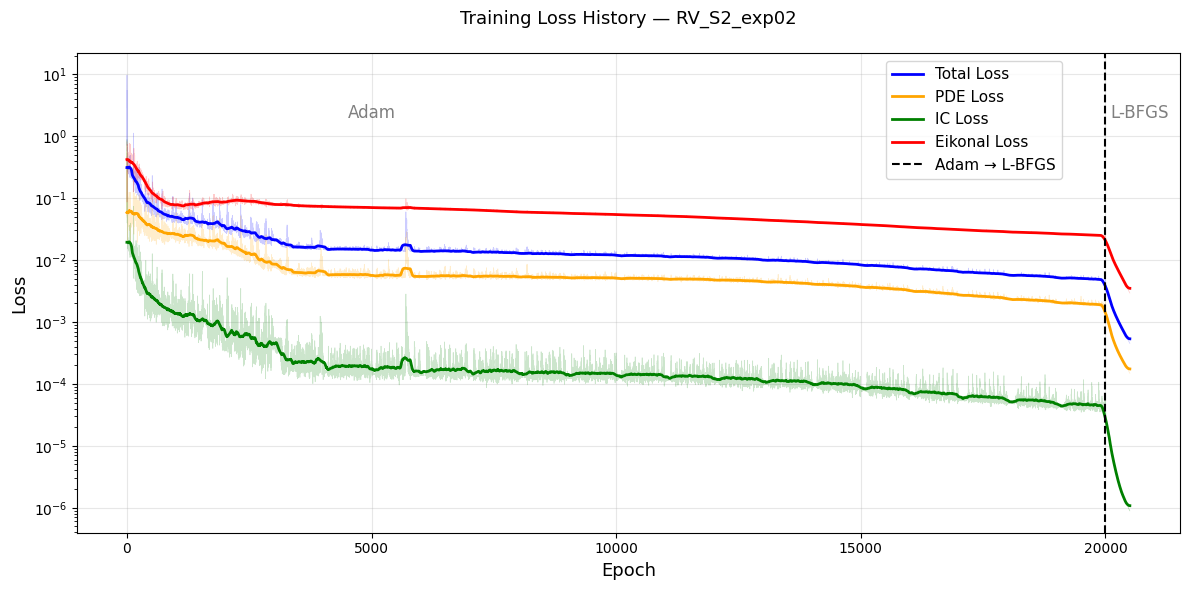

Saved


In [4]:
# ===========================
# Training Loss History
# ===========================
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import uniform_filter1d

history = checkpoint['history']
epochs = np.array(history['epoch'])
total  = np.array(history['total'])
pde    = np.array(history['pde'])
ic     = np.array(history['ic'])
eik    = np.array(history['eik'])

fig, ax = plt.subplots(figsize=(12, 6))

# Raw losses
colors = {'total': 'blue', 'pde': 'orange', 'ic': 'green', 'eik': 'red'}
ax.semilogy(epochs, total, color=colors['total'], alpha=0.2, linewidth=0.5)
ax.semilogy(epochs, pde,   color=colors['pde'],   alpha=0.2, linewidth=0.5)
ax.semilogy(epochs, ic,    color=colors['ic'],    alpha=0.2, linewidth=0.5)
ax.semilogy(epochs, eik,   color=colors['eik'],   alpha=0.2, linewidth=0.5)

# Smoothed trend lines
window = 200
for data, color, label in [
    (total, colors['total'], 'Total Loss'),
    (pde,   colors['pde'],   'PDE Loss'),
    (ic,    colors['ic'],    'IC Loss'),
    (eik,   colors['eik'],   'Eikonal Loss'),
]:
    log_smoothed = uniform_filter1d(
        np.log10(np.clip(data, 1e-12, None)), size=window
    )
    ax.semilogy(epochs, 10**log_smoothed, color=color, linewidth=2, label=label)

# Adam / LBFGS separator
ax.axvline(x=adam_epochs, color='black', linestyle='--',
           linewidth=1.5, label='Adam → L-BFGS')
ax.text(5000, 2.0,  'Adam',   fontsize=12, ha='center', color='black', alpha=0.5)
ax.text(20100, 2.0,  'L-BFGS', fontsize=12, ha='left',   color='black', alpha=0.5)

ax.set_xlabel('Epoch', fontsize=13)
ax.set_ylabel('Loss',  fontsize=13)
ax.set_title(
    'Training Loss History — RV_S2_exp02\n',
    fontsize=13
)
ax.legend(fontsize=11, loc='upper right', bbox_to_anchor=(0.90, 1.00))
ax.grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig('/content/drive/MyDrive/fig_training_loss_RV_S2_exp02.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved")

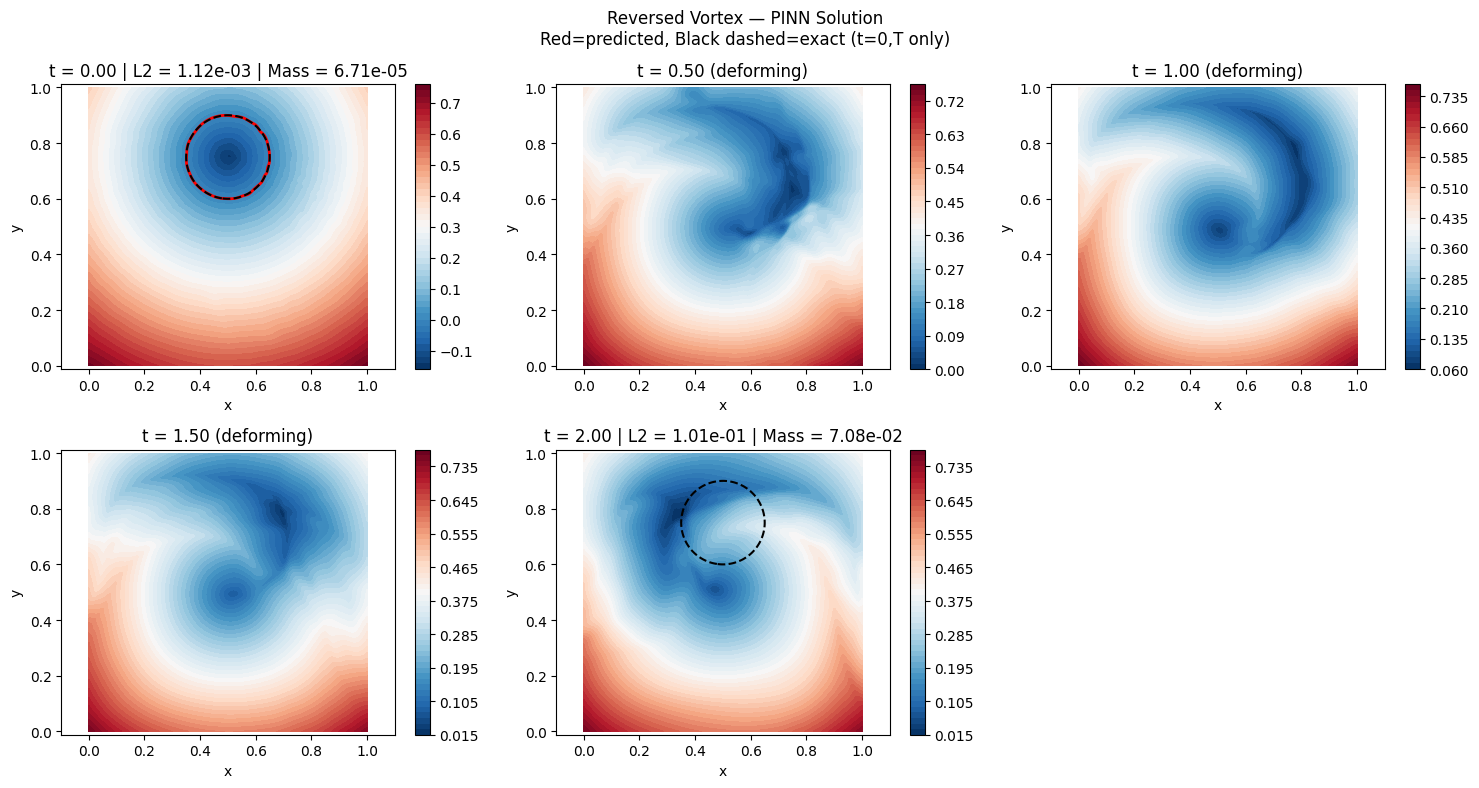

In [5]:
# ===========================
# Evaluation
# ===========================
import matplotlib.pyplot as plt

times = [0.0, T_final/4, T_final/2, 3*T_final/4, T_final]
nx = 300

x = np.linspace(0, 1, nx)
y = np.linspace(0, 1, nx)
X, Y = np.meshgrid(x, y)

# ── Error computation function ──
def compute_errors(phi_pred, X, Y):
    """L2 and mass error vs exact solution (circle at 0.5, 0.75, r=0.15)"""
    phi_exact = np.sqrt((X - 0.5)**2 + (Y - 0.75)**2) - 0.15

    # L2 error
    l2 = np.sqrt(np.mean((phi_pred - phi_exact)**2))

    # Mass error: area enclosed by phi<0
    dx = x[1] - x[0]
    dy = y[1] - y[0]
    mass_pred  = np.sum(phi_pred  < 0) * dx * dy
    mass_exact = np.sum(phi_exact < 0) * dx * dy
    mass_err = abs(mass_pred - mass_exact)

    return l2, mass_err

plt.figure(figsize=(15, 8))

l2_errors = []
mass_errors = []
for i, t_val in enumerate(times):
    t_norm = t_val / T_final
    XYT = torch.tensor(
        np.stack([X.flatten(), Y.flatten(), t_norm * np.ones_like(X.flatten())], axis=1),
        dtype=torch.float32, device=device
    )
    with torch.no_grad():
        phi = model(XYT).cpu().numpy().reshape(nx, nx)

    plt.subplot(2, 3, i + 1)
    plt.contourf(X, Y, phi, levels=50, cmap='RdBu_r')
    plt.colorbar()
    plt.contour(X, Y, phi, levels=[0], colors='red', linewidths=2)

    # Add errors only at t=0 and t=T
    if np.isclose(t_val, 0.0) or np.isclose(t_val, T_final):
        l2, mass_err = compute_errors(phi, X, Y)
        l2_errors.append(l2)
        mass_errors.append(mass_err)

        # Also draw exact circle in black for comparison
        phi_exact = np.sqrt((X - 0.5)**2 + (Y - 0.75)**2) - 0.15
        plt.contour(X, Y, phi_exact, levels=[0], colors='black',
                    linewidths=1.5, linestyles='--')
        plt.title(f"t = {t_val:.2f} | L2 = {l2:.2e} | Mass = {mass_err:.2e}")
    else:
        plt.title(f"t = {t_val:.2f} (deforming)")

    plt.axis("equal")
    plt.xlabel("x"); plt.ylabel("y")

plt.suptitle("Reversed Vortex — PINN Solution\nRed=predicted, Black dashed=exact (t=0,T only)",
             fontsize=12)
plt.tight_layout()
plt.show()

In [6]:
import csv

# CONFIG
EXP_ID           = 'RV_S2_exp02'
BENCHMARK        = 'RV'
SAMPLING         = 'uniform'
SCHEDULER        = 'StepLR'
SCHEDULER_PARAMS = 'step_1000_gamma_0.9'
T_NORMALIZED     = True
CSV_PATH         = '/content/drive/MyDrive/RV_S2_eikonal_study.csv'

row = {
    'exp_id':           EXP_ID,
    'benchmark':        BENCHMARK,
    'N_f':              N_f,
    'N_i':              N_i,
    'layers':           LAYERS,
    'neurons':          NEURONS,
    'w_pde':            w_pde,
    'w_ic':             w_ic,
    'w_eik':            w_eik,
    'adam_epochs':      adam_epochs,
    'lbfgs_epochs':     lbfgs_epochs,
    'scheduler':        SCHEDULER,
    'scheduler_params': SCHEDULER_PARAMS,
    'sampling':         SAMPLING,
    't_normalized':     T_NORMALIZED,
    'L2_t0':            f'{l2_errors[0]:.4e}',
    'L2_tT':            f'{l2_errors[-1]:.4e}',
    'avg_L2':           f'{np.mean(l2_errors):.4e}',
    'mass_t0':          f'{mass_errors[0]:.4e}',
    'mass_tT':          f'{mass_errors[-1]:.4e}',
    'avg_mass':         f'{np.mean(mass_errors):.4e}',
    'training_time':    checkpoint['training_time']
}

with open(CSV_PATH, 'a', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=row.keys())
    if f.tell() == 0:
        writer.writeheader()
    writer.writerow(row)

print(f'Row appended → {CSV_PATH}')

Row appended → /content/drive/MyDrive/RV_S2_eikonal_study.csv
